Не знаю что вы раньше прочитаете, но есть вторая(точнее первая) вариация лабы с аниме девочками с датасетом в 5700 картинок, её я тоже запушу, не зря же аниме девочек фильтровал (да и просто прикольно было). Код по факту что там что тут одинаковый, т.к. на больший картинках слишком много шума, а датасет маловат для таких приколов (да я много что перепробовал аж лимитов везде достиг).

Обучил у себя на пк, потому что я много эксперементировал с гиперпараметрами и потратил всё время в коллабе и кейгле. В качестве датасета используется иконки, я хотел написать код парсера, но по сле того как я случайно скачал html страничку заметил, что иконки тоже скачались)))

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imageio

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch_directml
from torchvision import transforms
from torch.optim.lr_scheduler import CosineAnnealingLR

DATA_PATH = 'C:/Users/Андрей/Desktop/Icons'
IMG_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 512
LR = 1e-4
EPOCHS = 100
DEVICE = torch_directml.device()

print(f"Device: {DEVICE}")

Device: privateuseone:0


In [3]:
class AnimeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [os.path.join(root_dir, f) for f in os.listdir(root_dir)
                            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.avif'))]
        print(f"Found {len(self.image_paths)} images.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert("RGBA")
            
            background = Image.new('RGB', image.size, (255, 255, 255))
            background.paste(image, mask=image.split()[-1])
            
            if self.transform:
                background = self.transform(background)
            return background
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            return self.__getitem__(random.randint(0, len(self.image_paths)-1))

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


In [4]:
from torch.utils.data import random_split

dataset = AnimeDataset(DATA_PATH, transform=transform)

dataset_size = len(dataset)
train_size = int(0.9 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Train: {len(train_dataset)} images")
print(f"Validation: {len(val_dataset)} images")

Found 1554 images.
Train: 1398 images
Validation: 156 images


Модель Variational AutoEncoder. Выбрал его потому что он показался мне интересным, а ещё он лучше генерит чем обычный AutoEncoder

In [5]:
class VAutoEncoder(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super(VAutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
        )

        self.fc_mu = nn.Linear(512 * 4 * 4, LATENT_DIM)
        self.fc_logvar = nn.Linear(512 * 4 * 4, LATENT_DIM)

        self.decoder_input = nn.Linear(LATENT_DIM, 512 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (512, 4, 4)),

            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),


            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decoder(self.decoder_input(z))
        return reconstruction, mu, logvar

model = VAutoEncoder().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
recon = nn.L1Loss(reduction='mean')

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

#model.load_state_dict(torch.load("best_vae.pth", map_location=DEVICE))

### Обучение (вот бы было ЕГЭ по аниме девочкам)

Функция обучения одной эпохи

In [6]:
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch_idx, images in enumerate(dataloader):
        images = images.to(device)
        optimizer.zero_grad()

        recon_images, mu, logvar = model(images)
        loss = recon(recon_images, images)

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)

    return avg_loss

Валидация

In [7]:
def validate(model, dataloader, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch_idx, images in enumerate(dataloader):
            images = images.to(device)

            recon_images, mu, logvar = model(images)

            loss = recon(recon_images, images)

            total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)

    return avg_loss

Я даже уже не знаю сколько конкретно эпох (около 150), потому что останавливал обучение для проверки а потом шаманил с параметрами, а иногда и саму модель дорабатывал

In [8]:
print("Starting training")

best_val_loss = 1

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_dataloader, optimizer, DEVICE)

    val_loss = validate(model, val_dataloader, DEVICE)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_vae.pth")
        print("Saved new best model")

    print(f"Epoch {epoch+1:3d}/{EPOCHS}: "
          f"Train Loss: {train_loss:.4f}  | Val Loss: {val_loss:.4f}")

Starting training


c:\Users\Андрей\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Saved new best model
Epoch   1/100: Train Loss: 0.4098  | Val Loss: 0.4048
Saved new best model
Epoch   2/100: Train Loss: 0.3474  | Val Loss: 0.3239
Saved new best model
Epoch   3/100: Train Loss: 0.3179  | Val Loss: 0.3000
Saved new best model
Epoch   4/100: Train Loss: 0.3049  | Val Loss: 0.2974
Saved new best model
Epoch   5/100: Train Loss: 0.3024  | Val Loss: 0.2972
Saved new best model
Epoch   6/100: Train Loss: 0.2982  | Val Loss: 0.2854
Saved new best model
Epoch   7/100: Train Loss: 0.2837  | Val Loss: 0.2641
Saved new best model
Epoch   8/100: Train Loss: 0.2587  | Val Loss: 0.2299
Saved new best model
Epoch   9/100: Train Loss: 0.2295  | Val Loss: 0.1972
Saved new best model
Epoch  10/100: Train Loss: 0.2034  | Val Loss: 0.1844
Saved new best model
Epoch  11/100: Train Loss: 0.1835  | Val Loss: 0.1710
Saved new best model
Epoch  12/100: Train Loss: 0.1720  | Val Loss: 0.1674
Saved new best model
Epoch  13/100: Train Loss: 0.1671  | Val Loss: 0.1658
Saved new best model
Epoc

Генерация интерполяции

GIF saved as anime_morph.gif


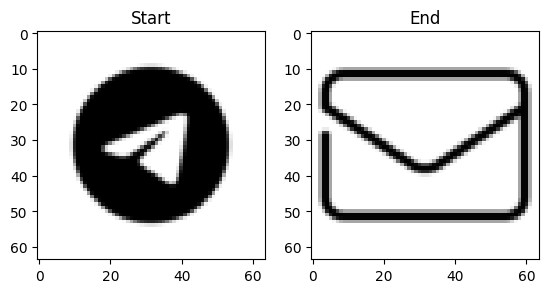

In [9]:
def generate_interpolation_gif(model, dataset, filename='anime_morph.gif', steps=30):
    model.eval()

    idx_a = 1333
    idx_b = 1000
    img_a = dataset[idx_a].unsqueeze(0).to(DEVICE)
    img_b = dataset[idx_b].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        _, mu_a, logvar_a = model(img_a)
        _, mu_b, logvar_b = model(img_b)

        z_a = mu_a
        z_b = mu_b

        frames = []
        for alpha in np.linspace(0, 1, steps):
            z = z_a * (1 - alpha) + z_b * alpha
            h_dec = model.decoder_input(z)
            recon = model.decoder(h_dec)

            img_np = recon.squeeze().cpu().permute(1, 2, 0).numpy()
            img_np = (img_np * 255).astype(np.uint8)
            frames.append(img_np)

    imageio.mimsave(filename, frames, fps=10)
    print(f"GIF saved as {filename}")

    plt.figure(figsize=(10,5))
    plt.subplot(1,3,1)
    plt.imshow(img_a.squeeze().cpu().permute(1, 2, 0))
    plt.title("Start")

    plt.subplot(1,3,2)
    plt.imshow(img_b.squeeze().cpu().permute(1, 2, 0))
    plt.title("End")

    plt.show()


generate_interpolation_gif(model, dataset, steps=50)

Генерация из случайного шума.

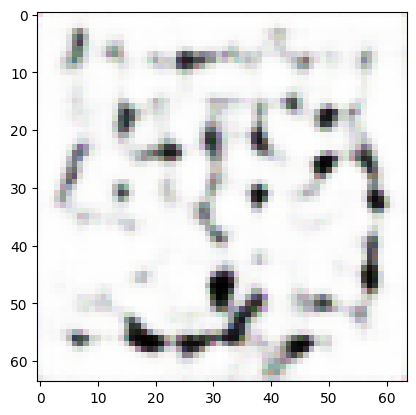

In [14]:
with torch.no_grad():
    z = torch.randn(1, LATENT_DIM).to(DEVICE)
    samples = model.decoder(model.decoder_input(z))

    plt.imshow(samples[0].permute(1, 2, 0).cpu())

Посмотрим как восстанавливает

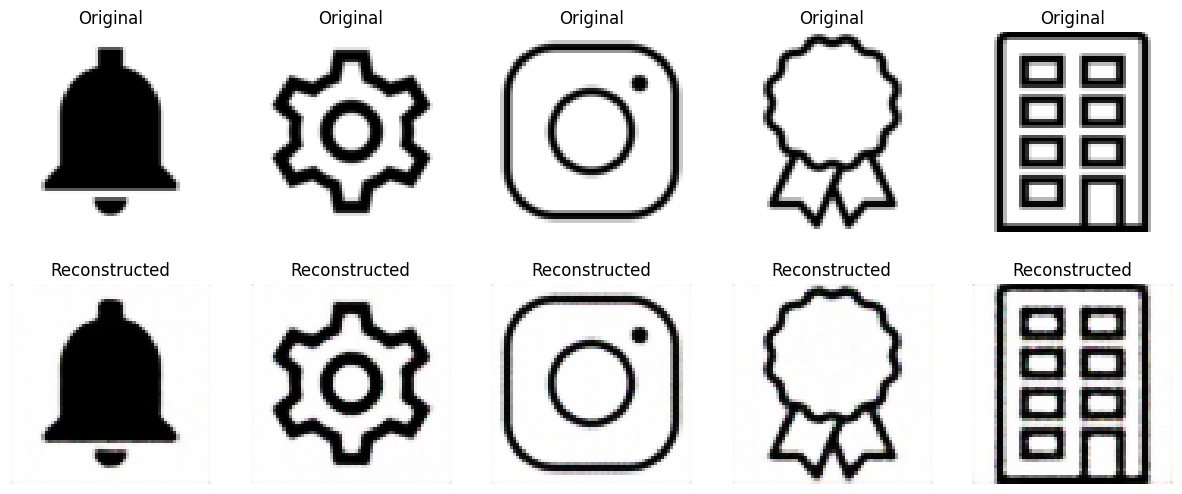

In [11]:
model.eval()
with torch.no_grad():
    indices = [random.randint(0, len(dataset)-1) for _ in range(5)]
    real_images = torch.stack([dataset[i] for i in indices]).to(DEVICE)

    reconstructed, _, _ = model(real_images)

    plt.figure(figsize=(15, 6))
    for i in range(5):
        plt.subplot(2, 5, i+1)
        plt.imshow(real_images[i].cpu().permute(1, 2, 0))
        plt.axis('off')
        plt.title("Original")

        plt.subplot(2, 5, i+6)
        plt.imshow(reconstructed[i].cpu().permute(1, 2, 0))
        plt.axis('off')
        plt.title("Reconstructed")

    plt.show()

В принципе работает, хотелось бы датасет побольше или поконкретнее(типа только аниме лица), но чисто картинки аниме лиц найти трудно, а вырезать уйдёт вечность